📊 Tier Summary (Centroid Means):


,TotalRevenue,TotalProfit,ProfitMargin,TotalCost,UnitPrice_mean_x,PriceVolatility,SalesQty_sum,SalesFrequency,AvgOrderQuantity,ProductLifetimeDays,CustomerBase,CustomerPenetration,RevenuePerCustomer,OrdersPerCustomer,QuoteConversionRate,QuoteWinRate,AvgQuoteNegotiations
Tier,,,,,,,,,,,,,,,,,
1,515.42,127.15,0.23,388.27,87.45,0.03,540.77,279.96,380.54,63.15,1.07,0.00,500.98,1.30,1.61,0.48,1.44
2,10144.20,-4532783.40,-446.83,4542927.60,0.09,0.11,113000.00,10.07,3138.89,1304.00,1.00,0.00,10144.20,36.00,0.80,0.48,1.24
3,6466.41,1994.98,0.33,4471.43,43.21,0.20,34147.26,32.58,803.32,792.13,1.92,0.00,4505.72,23.66,0.87,0.53,1.22
4,371736.78,105870.31,0.30,265866.48,23.23,1.04,4114108.20,247.55,17100.10,1240.03,2.48,0.00,224100.61,621.90,0.89,0.54,1.22
5,465.89,123.64,0.25,342.25,76.84,0.03,482.81,295.32,351.29,57.52,1.06,0.00,447.90,1.54,0.86,0.86,1.00
6,14254.81,4717.05,0.40,9537.75,39.23,0.66,77217.34,37.57,291.03,1222.69,17.56,0.02,874.90,7.46,0.88,0.54,1.22


📦 Product Segmentation (ProductID → Tier → Label):


,ProductID,Tier,TierLabel
0,SYE-342-DS4,1,Mid Performer / Stable
1,VOW-355-VC9,1,Mid Performer / Stable
2,VOW-601-US7,1,Mid Performer / Stable
3,JAU-587-EC1,1,Mid Performer / Stable
4,DRE-638-IW4,1,Mid Performer / Stable
5,VPB-051-YJ1,1,Mid Performer / Stable
6,VPB-620-DW7,1,Mid Performer / Stable
7,PCY-371-MK2,1,Mid Performer / Stable
8,DQX-263-AJ7,1,Mid Performer / Stable
9,DQX-224-UM5,1,Mid Performer / Stable


✅ Full segmentation file saved as 'product_segmentation_labeled.csv'


C:\Users\Araya\AppData\Local\Temp\ipykernel_26896\968183135.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="TierLabel", order=tier_summary["TierLabel"], palette="viridis")


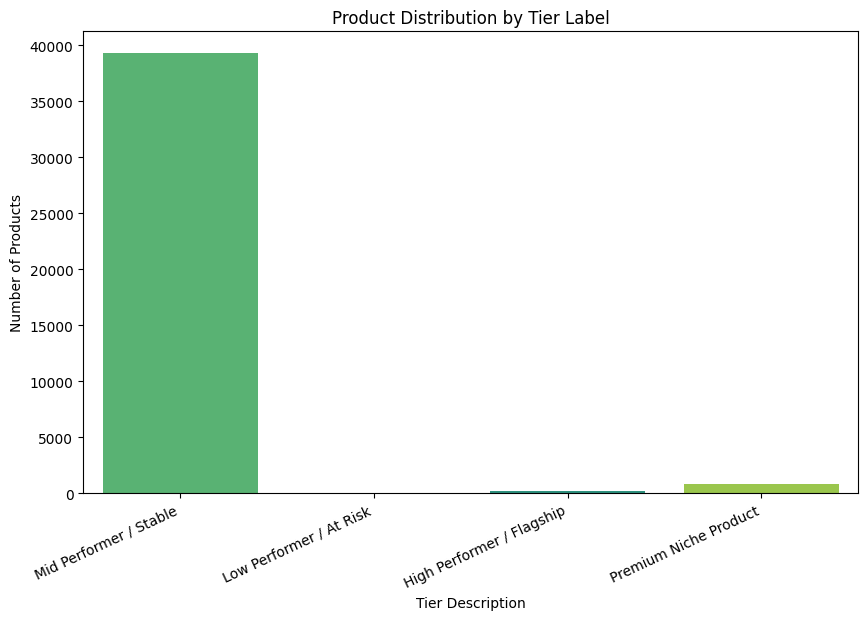

,PerformanceScore,DemandScore,StabilityScore,TierLabel
Tier,,,,
1,0.590859,0.284698,0.700000,Mid Performer / Stable
2,0.010427,0.013676,0.780918,Low Performer / At Risk
3,0.597476,0.038877,0.732178,Mid Performer / Stable
4,0.999955,0.767634,0.150000,High Performer / Flagship
5,0.590814,0.300725,1.000000,Mid Performer / Stable
6,0.606133,0.238249,0.413366,Premium Niche Product


In [7]:
# ===========================================
# 🧠 Product Tier Segmentation with Descriptive Labels
# ===========================================
# This notebook clusters products into 6 performance tiers using K-Means,
# then automatically names each tier based on centroid characteristics.
# ===========================================

# --- Imports ---
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load Data ---
df = pd.read_csv(r"C:\Users\Araya\Desktop\segementation Data enchnaced\product_features_enhanced (2).csv")

# --- Feature Selection ---
selected_features = [
    "TotalRevenue", "TotalProfit", "ProfitMargin", "TotalCost",
    "UnitPrice_mean_x", "PriceVolatility",
    "SalesQty_sum", "SalesFrequency", "AvgOrderQuantity", "ProductLifetimeDays",
    "CustomerBase", "CustomerPenetration", "RevenuePerCustomer", "OrdersPerCustomer",
    "QuoteConversionRate", "QuoteWinRate", "AvgQuoteNegotiations"
]

# --- Why These Features? ---
# Financial metrics → Value creation
# Pricing metrics → Market position
# Demand metrics → Sales velocity
# Customer metrics → Reach and loyalty
# Quote metrics → Conversion efficiency

# --- Data Preparation ---
X = df[selected_features].replace([np.inf, -np.inf], np.nan).fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- K-Means Clustering ---
kmeans = KMeans(n_clusters=6, random_state=42, n_init=20)
df["Tier"] = kmeans.fit_predict(X_scaled) + 1

# --- Analyze Each Cluster ---
tier_summary = df.groupby("Tier")[selected_features].mean().round(2)
print("📊 Tier Summary (Centroid Means):")
display(tier_summary)

# --- Automatic Tier Labeling ---
# Step 1: Normalize each feature to 0–1 range for relative comparison
tier_norm = (tier_summary - tier_summary.min()) / (tier_summary.max() - tier_summary.min())

# Step 2: Compute key axes
tier_summary["PerformanceScore"] = (
    tier_norm["TotalRevenue"] * 0.4 +
    tier_norm["TotalProfit"] * 0.4 +
    tier_norm["ProfitMargin"] * 0.2
)

tier_summary["DemandScore"] = (
    tier_norm["SalesQty_sum"] * 0.5 +
    tier_norm["SalesFrequency"] * 0.3 +
    tier_norm["CustomerBase"] * 0.2
)

tier_summary["StabilityScore"] = (
    (1 - tier_norm["PriceVolatility"]) * 0.7 +
    (1 - tier_norm["AvgQuoteNegotiations"]) * 0.3
)

# Step 3: Rank clusters and create descriptive labels
labels = []
for i, row in tier_summary.iterrows():
    if row["PerformanceScore"] > 0.7 and row["DemandScore"] > 0.7:
        labels.append("High Performer / Flagship")
    elif row["PerformanceScore"] > 0.6 and row["DemandScore"] < 0.6:
        labels.append("Premium Niche Product")
    elif row["PerformanceScore"] < 0.4 and row["DemandScore"] > 0.6:
        labels.append("High Volume / Low Margin")
    elif row["PerformanceScore"] < 0.4 and row["DemandScore"] < 0.4:
        labels.append("Low Performer / At Risk")
    elif row["StabilityScore"] < 0.4:
        labels.append("Unstable / Price Sensitive")
    else:
        labels.append("Mid Performer / Stable")
        
tier_summary["TierLabel"] = labels

# Map back to dataframe
label_map = tier_summary["TierLabel"].to_dict()
df["TierLabel"] = df["Tier"].map(label_map)

# --- Final Product Segmentation Output ---
product_segments = df[["ProductID", "Tier", "TierLabel"]].sort_values("Tier").reset_index(drop=True)
print("📦 Product Segmentation (ProductID → Tier → Label):")
display(product_segments.head(20))

# --- Save Complete Output ---
product_segments.to_csv("product_segmentation_labeled.csv", index=False)
print("✅ Full segmentation file saved as 'product_segmentation_labeled.csv'")

# --- Visualization ---
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="TierLabel", order=tier_summary["TierLabel"], palette="viridis")
plt.title("Product Distribution by Tier Label")
plt.xticks(rotation=25, ha="right")
plt.ylabel("Number of Products")
plt.xlabel("Tier Description")
plt.show()

# --- Display final tier summary ---
display(tier_summary[["PerformanceScore", "DemandScore", "StabilityScore", "TierLabel"]])
